# MVTec AD - the split, the resize, and what a 0.3 per cent defect survives

**Arkon Manufacturing AI | Module: CV Anomaly | Department: Component Inspection**

Notebook 01 measured the four categories and found two things this notebook has
to act on: the median defect covers between 0.29 and 3.7 per cent of its frame,
and the four categories are four imaging setups rather than one. Every choice
below is measured rather than declared, because a defect this small can be
destroyed by a preprocessing step and nothing downstream would report it.

Three decisions are settled here. How the training folder is cut, and why an
anomaly detector needs a piece of it that never enters the model. What the
network is actually shown, and whether the defect is still in the picture
afterwards. And whether the memory bank may be augmented, which for this method
is a different question from what it is for a classifier.

In [1]:
import sys
from pathlib import Path

# notebooks/ holds the shared helpers; this notebook sits two levels below it
_nb_root = Path('../..').resolve()
if str(_nb_root) not in sys.path:
    sys.path.insert(0, str(_nb_root))

from utils.arkon_utils import save_figure

print('arkon_utils loaded')

arkon_utils loaded


## 1. Imports and configuration

Nothing is imported from a training script. This module has none: the three
notebooks in this folder are the whole of it, and this one holds the choices
notebook 03 rebuilds.

In [2]:
import platform

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from PIL import Image
from torchvision import models, transforms

plt.style.use('seaborn-v0_8-darkgrid')

ASSETS = 'cv'
RAW_DIR = Path('../../../data/05_mvtec/raw')
CATEGORIES = sorted(d.name for d in RAW_DIR.iterdir() if d.is_dir())

SEED = 42
CALIBRATION_FRACTION = 0.30
IMAGE_SIZES = (224, 320)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
# ResNet-18 output strides: the side of the feature grid is the input size over these
LAYER_STRIDES = {'layer1': 4, 'layer2': 8, 'layer3': 16, 'layer4': 32}
DIAGNOSTIC_BANK_PATCHES = 8192   # subsampled bank, used only for the augmentation test

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(SEED)
pd.set_option('display.width', 130)
print(f'python  {sys.version.split()[0]}   torch {torch.__version__}')
print(f'device  {DEVICE}'
      + (f'  {torch.cuda.get_device_name(0)}' if DEVICE.type == 'cuda' else ''))
print(f'machine {platform.system()} {platform.machine()}')

python  3.12.10   torch 2.6.0+cu124
device  cuda  NVIDIA GeForce RTX 3070 Laptop GPU
machine Windows AMD64


## 2. Cutting the training folder into a memory bank and a calibration set

A classifier splits its training data to choose an operating point on labelled
mistakes. This module has no labelled mistake anywhere in its training data:
every training image is a sound part. What it needs the second piece for is
different, and it is the reason the split exists at all.

The model will score a part by how far it sits from the sound parts it holds.
To turn that distance into a decision, somebody has to say how far is too far,
and the only honest source for that is sound parts the model does not already
hold. Score a part that is inside the memory bank and it is compared against a
copy of itself, so its distance is near zero by construction and says nothing
about the distances a new sound part will produce.

**This is also where the casting lesson lands.** Casting chose its operating
point by searching a cost curve computed on scored data, and the chosen point
moved by a factor of five between runs of identical code because the curve was
nearly flat and the scores moved underneath it. The rule below never searches.
It states a false-alarm budget on sound parts and reads the threshold off the
calibration distribution, so there is no minimum for run-to-run noise to
relocate.

In [3]:
rng = np.random.default_rng(SEED)
split = {}
rows = []
for category in CATEGORIES:
    good = sorted((RAW_DIR / category / 'train' / 'good').glob('*.png'))
    order = rng.permutation(len(good))
    n_calibration = int(round(len(good) * CALIBRATION_FRACTION))
    calibration = [good[i] for i in sorted(order[:n_calibration])]
    bank = [good[i] for i in sorted(order[n_calibration:])]
    split[category] = {'bank': bank, 'calibration': calibration}
    test_good = sorted((RAW_DIR / category / 'test' / 'good').glob('*.png'))
    test_defect = [p for folder in sorted((RAW_DIR / category / 'test').iterdir())
                   if folder.is_dir() and folder.name != 'good'
                   for p in sorted(folder.glob('*.png'))]
    rows.append({'category': category, 'bank': len(bank), 'calibration': len(calibration),
                 'test_good': len(test_good), 'test_defect': len(test_defect)})

composition = pd.DataFrame(rows).set_index('category')
print(composition.to_string())
print()
print(f'The cut is {1 - CALIBRATION_FRACTION:.0%}/{CALIBRATION_FRACTION:.0%} at seed {SEED}, '
      f'drawn once per category. Nothing is stratified,')
print('because there is exactly one class in the training folder and nothing to')
print('stratify on.')
print()
print(f'The calibration sets hold {composition["calibration"].min()} to '
      f'{composition["calibration"].max()} sound parts. That is what limits the')
print('false-alarm budget the threshold can be stated at: a budget of 1 per cent would')
print(f'be the single highest score in a set of {composition["calibration"].min()}, which is an '
      f'extreme value rather than')
print('a percentile. Notebook 03 states the budget at 5 per cent for that reason and')
print('records it as a limitation rather than a preference.')

            bank  calibration  test_good  test_defect
category                                             
grid         185           79         21           57
metal_nut    154           66         22           93
screw        224           96         41          119
transistor   149           64         60           40

The cut is 70%/30% at seed 42, drawn once per category. Nothing is stratified,
because there is exactly one class in the training folder and nothing to
stratify on.

The calibration sets hold 64 to 96 sound parts. That is what limits the
false-alarm budget the threshold can be stated at: a budget of 1 per cent would
be the single highest score in a set of 64, which is an extreme value rather than
a percentile. Notebook 03 states the budget at 5 per cent for that reason and
records it as a limitation rather than a preference.


  ✓ Saved → assets\cv\mvtec_prep_split.png


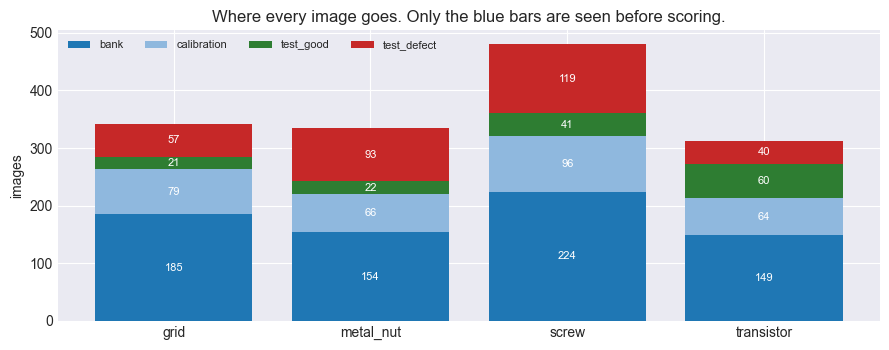

In [4]:
fig, ax = plt.subplots(figsize=(9, 3.6))
bottom = np.zeros(len(composition))
colours = {'bank': '#1f77b4', 'calibration': '#8fb8de',
           'test_good': '#2e7d32', 'test_defect': '#c62828'}
for column, colour in colours.items():
    ax.bar(composition.index, composition[column], bottom=bottom, label=column, color=colour)
    for x, (value, base) in enumerate(zip(composition[column], bottom)):
        if value:
            ax.text(x, base + value / 2, str(value), ha='center', va='center',
                    fontsize=8, color='white')
    bottom += composition[column].to_numpy()
ax.set_ylabel('images')
ax.set_title('Where every image goes. Only the blue bars are seen before scoring.')
ax.legend(ncol=4, fontsize=8)
fig.tight_layout()
save_figure(fig, 'mvtec_prep_split', subfolder=ASSETS)
plt.show()

## 3. What the network is actually shown

Two of the four categories are greyscale and an ImageNet backbone expects three
channels, so a conversion happens whether or not anybody chooses it. The cell
checks what that conversion does rather than assuming it is harmless, and
confirms that a square resize is safe here.

In [5]:
sample_paths = {category: split[category]['bank'][0] for category in CATEGORIES}
checks = []
for category, path in sample_paths.items():
    with Image.open(path) as image:
        mode, size = image.mode, image.size
        rgb = np.asarray(image.convert('RGB'))
    identical_channels = bool((rgb[:, :, 0] == rgb[:, :, 1]).all() and (rgb[:, :, 1] == rgb[:, :, 2]).all())
    checks.append({'category': category, 'mode': mode, 'size': f'{size[0]}x{size[1]}',
                   'square': size[0] == size[1],
                   'rgb_channels_identical': identical_channels})

print(pd.DataFrame(checks).to_string(index=False))
print()
print('Every image is square, so resizing to a square costs no aspect ratio. The two')
print('greyscale categories become three identical channels, which is the standard')
print('conversion and adds no information: what it does is let a colour backbone see a')
print('monochrome part at all. The two colour categories keep their channels.')
print()
print('Normalisation uses the ImageNet statistics rather than per-category statistics,')
print('because the backbone is frozen: its filters were fitted under exactly these')
print('constants and re-centring the input would move every activation away from the')
print('regime they were trained in. Nothing here is being fine-tuned, so there is no')
print('argument for dataset statistics.')

  category mode      size  square  rgb_channels_identical
      grid    L 1024x1024    True                    True
 metal_nut  RGB   700x700    True                   False
     screw    L 1024x1024    True                    True
transistor  RGB 1024x1024    True                   False

Every image is square, so resizing to a square costs no aspect ratio. The two
greyscale categories become three identical channels, which is the standard
conversion and adds no information: what it does is let a colour backbone see a
monochrome part at all. The two colour categories keep their channels.

Normalisation uses the ImageNet statistics rather than per-category statistics,
because the backbone is frozen: its filters were fitted under exactly these
constants and re-centring the input would move every activation away from the
regime they were trained in. Nothing here is being fine-tuned, so there is no
argument for dataset statistics.


  ✓ Saved → assets\cv\mvtec_prep_batch.png


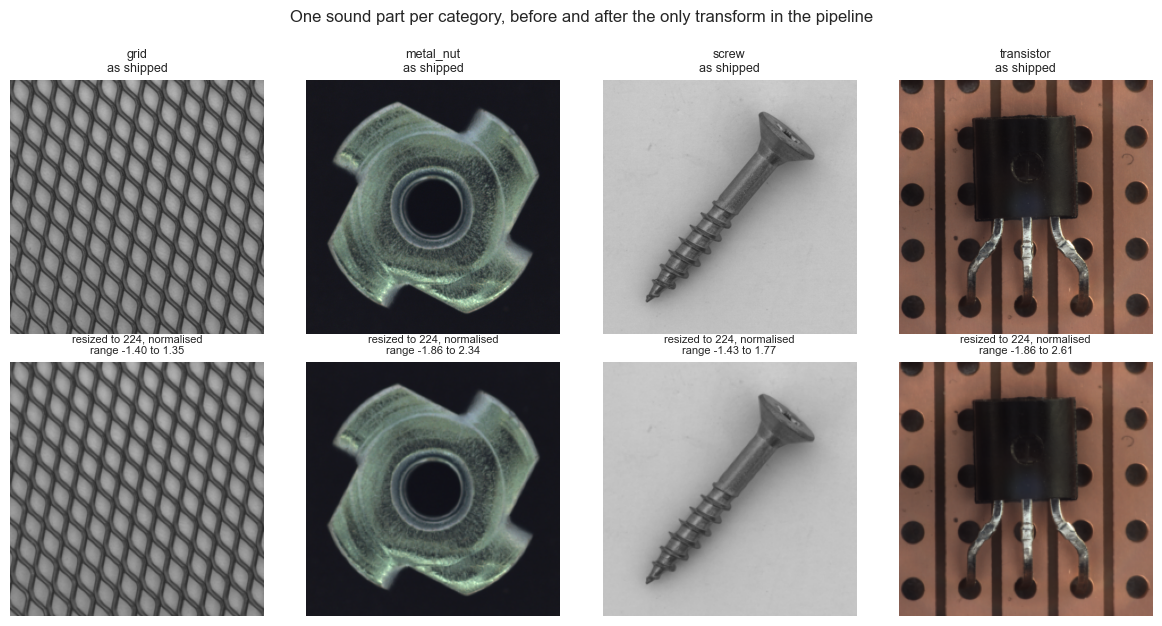

batch tensor (4, 3, 224, 224), dtype torch.float32


In [6]:
def load_batch(paths, size):
    """Load images the way the module will: square resize, RGB, ImageNet normalisation."""
    pipeline = transforms.Compose([
        transforms.Resize((size, size)),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])
    return torch.stack([pipeline(Image.open(p).convert('RGB')) for p in paths])


batch = load_batch([sample_paths[c] for c in CATEGORIES], IMAGE_SIZES[0])
denormalised = batch * torch.tensor(IMAGENET_STD).view(1, 3, 1, 1) + torch.tensor(IMAGENET_MEAN).view(1, 3, 1, 1)
fig, axes = plt.subplots(2, len(CATEGORIES), figsize=(3.0 * len(CATEGORIES), 6.2))
for column, category in enumerate(CATEGORIES):
    axes[0][column].imshow(Image.open(sample_paths[category]).convert('RGB'))
    axes[0][column].set_title(f'{category}\nas shipped', fontsize=9)
    axes[1][column].imshow(denormalised[column].permute(1, 2, 0).clamp(0, 1).numpy())
    axes[1][column].set_title(f'resized to {IMAGE_SIZES[0]}, normalised\n'
                              f'range {batch[column].min():.2f} to {batch[column].max():.2f}',
                              fontsize=8)
    for axis in (axes[0][column], axes[1][column]):
        axis.set_xticks([])
        axis.set_yticks([])
fig.suptitle('One sound part per category, before and after the only transform in the pipeline',
             y=1.002)
fig.tight_layout()
save_figure(fig, 'mvtec_prep_batch', subfolder=ASSETS)
plt.show()
print(f'batch tensor {tuple(batch.shape)}, dtype {batch.dtype}')

## 4. Does the defect survive the resize

A 1024-pixel frame resized to 224 loses a factor of 4.6 in each direction, so a
defect of 2,600 pixels becomes about 124. The question is not rhetorical: a thin
scratch can fall below one pixel and disappear from the input entirely, and
every metric downstream would then be measured on an image where the thing being
detected is not present.

The masks are resized exactly as the evaluation later resizes them, with nearest
neighbour, and counted again.

In [7]:
def mask_at(path, size):
    """Ground truth mask at the model's input resolution, nearest neighbour."""
    with Image.open(path) as mask:
        return np.asarray(mask.convert('L').resize((size, size), Image.NEAREST)) > 0


survival = []
mask_paths = []
for category in CATEGORIES:
    for folder in sorted((RAW_DIR / category / 'ground_truth').iterdir()):
        if folder.is_dir():
            mask_paths.extend((category, folder.name, p) for p in sorted(folder.glob('*.png')))

for category, defect, path in mask_paths:
    with Image.open(path) as mask:
        native = np.asarray(mask.convert('L')) > 0
    row = {'category': category, 'defect': defect,
           'native_fraction': float(native.mean()), 'native_pixels': int(native.sum())}
    for size in IMAGE_SIZES:
        small = mask_at(path, size)
        row[f'pixels_at_{size}'] = int(small.sum())
        row[f'fraction_at_{size}'] = float(small.mean())
    survival.append(row)

survival = pd.DataFrame(survival)
summary = survival.groupby('category').agg(
    n=('native_pixels', 'size'),
    native_fraction=('native_fraction', 'median'),
    **{f'median_pixels_at_{s}': (f'pixels_at_{s}', 'median') for s in IMAGE_SIZES},
    **{f'vanished_at_{s}': (f'pixels_at_{s}', lambda column: int((column == 0).sum()))
       for s in IMAGE_SIZES}).round(4)
print(summary.to_string())
print()
vanished = {size: int((survival[f'pixels_at_{size}'] == 0).sum()) for size in IMAGE_SIZES}
print(f'masks that become empty at the input resolution: {vanished}')
print(f'smallest surviving defect at {IMAGE_SIZES[0]}: '
      f'{int(survival[survival[f"pixels_at_{IMAGE_SIZES[0]}"] > 0][f"pixels_at_{IMAGE_SIZES[0]}"].min())} pixels')
print()
print('No defect disappears at either size, so the resize is not destroying the target.')
print('What it does do is leave the smallest ones a few dozen pixels wide, and that is')
print('the number the next cell turns into a design decision.')

              n  native_fraction  median_pixels_at_224  median_pixels_at_320  vanished_at_224  vanished_at_320
category                                                                                                      
grid         57           0.0060                 312.0                 615.0                0                0
metal_nut    93           0.0367                1843.0                3756.0                0                0
screw       119           0.0029                 147.0                 295.0                0                0
transistor   40           0.0203                1012.0                2073.0                0                0

masks that become empty at the input resolution: {224: 0, 320: 0}
smallest surviving defect at 224: 50 pixels

No defect disappears at either size, so the resize is not destroying the target.
What it does do is leave the smallest ones a few dozen pixels wide, and that is
the number the next cell turns into a design decision.


## 5. Which feature grid still holds the defect

A frozen ResNet-18 offers four places to read features from, and they differ by
a factor of eight in spatial resolution. The skeleton notebook that shipped with
this repository reads `layer4` and averages it over the whole frame. Those are
two separate choices, they fail for different reasons, and they are measured
separately here.

Each feature cell summarises a square block of the input. Two numbers describe
what a defect looks like to a given grid. Its **extent** is how many cells it
touches at all. Its **purity** is how much of the most covered cell it actually
fills, and that is the one that decides whether the defect is visible: a cell
that is one per cent defect and ninety-nine per cent sound part produces a
feature vector that looks like a sound part.

The two move in opposite directions, which is why measuring only one of them
gives the wrong answer.

In [8]:
def cell_coverage(mask, grid):
    """Fraction of each feature cell covered by the defect, from the native mask."""
    edges = np.linspace(0, mask.shape[0], grid + 1).astype(int)
    rows = np.add.reduceat(mask.astype(np.int32), edges[:-1], axis=0)
    cells = np.add.reduceat(rows, edges[:-1], axis=1)
    sides = np.diff(edges)
    return cells / (sides[:, None] * sides[None, :])


coverage = []
for category, defect, path in mask_paths:
    with Image.open(path) as mask_file:
        native = np.asarray(mask_file.convert('L')) > 0
    for size in IMAGE_SIZES:
        for layer, stride in LAYER_STRIDES.items():
            grid = size // stride
            filled = cell_coverage(native, grid)
            coverage.append({'category': category, 'defect': defect, 'size': size,
                             'layer': layer, 'grid': f'{grid}x{grid}',
                             'cells_touched': int((filled > 0).sum()),
                             'extent': float((filled > 0).mean()),
                             'purity': float(filled.max())})

coverage = pd.DataFrame(coverage)
extent = coverage.pivot_table(index=['size', 'layer', 'grid'], columns='category',
                              values='cells_touched', aggfunc='median')
purity = coverage.pivot_table(index=['size', 'layer', 'grid'], columns='category',
                              values='purity', aggfunc='median')
print('Extent: median number of feature cells the defect touches at all')
print(extent.to_string())
print()
print('Purity: median share of the most covered cell that is actually defect')
print(purity.round(3).to_string())
print()
print(f'defects touching no cell at all: {int((coverage["cells_touched"] == 0).sum())}, '
      f'which is the control on the reduction rather than a result')

Extent: median number of feature cells the defect touches at all
category           grid  metal_nut  screw  transistor
size layer  grid                                     
224  layer1 56x56  38.0      170.0   19.0        95.0
     layer2 28x28  17.0       54.0    8.0        33.0
     layer3 14x14   9.0       20.0    4.0        12.0
     layer4 7x7     5.0        8.0    2.0         5.5
320  layer1 80x80  65.0      306.0   31.0       168.5
     layer2 40x40  26.0       97.0   12.0        52.5
     layer3 20x20  12.0       33.0    6.0        21.0
     layer4 10x10   7.0       13.0    3.0         9.0

Purity: median share of the most covered cell that is actually defect
category            grid  metal_nut  screw  transistor
size layer  grid                                      
224  layer1 56x56  1.000      1.000  1.000       1.000
     layer2 28x28  0.884      1.000  0.842       1.000
     layer3 14x14  0.366      0.998  0.346       0.906
     layer4 7x7    0.150      0.581  0.117       

Extent grows as the grid coarsens, because a larger cell is easier to touch.
Purity falls, because the same defect is a smaller part of a larger block. Read
extent alone and `layer4` looks like the best place to work; read purity and it
is the worst. Purity is the one a distance in feature space responds to.

  ✓ Saved → assets\cv\mvtec_prep_feature_grid.png


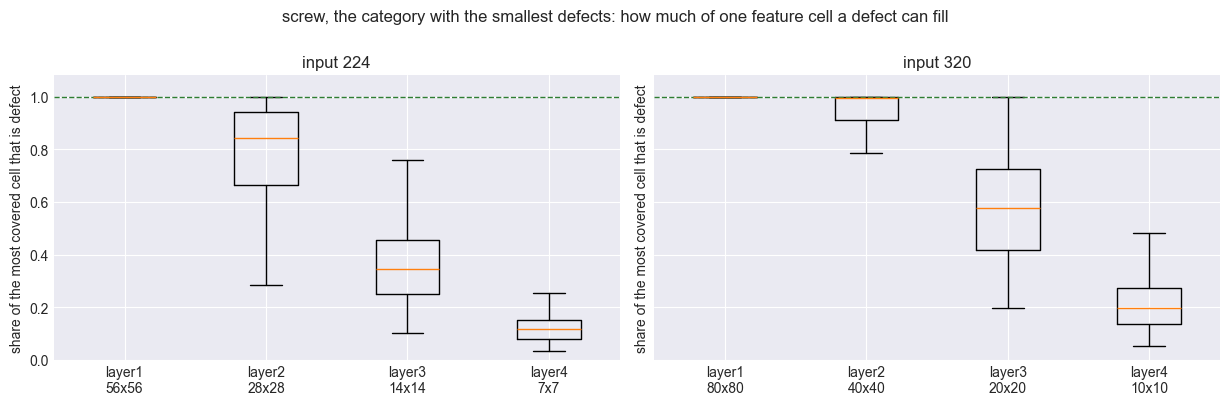

In [9]:
hardest = coverage.groupby('category')['purity'].median().idxmin()
worst = coverage[coverage.category == hardest]
fig, axes = plt.subplots(1, len(IMAGE_SIZES), figsize=(6.2 * len(IMAGE_SIZES), 4), sharey=True)
for axis, size in zip(np.atleast_1d(axes), IMAGE_SIZES):
    subset = worst[worst['size'] == size]
    layers = list(LAYER_STRIDES)
    axis.boxplot([subset[subset.layer == layer]['purity'].to_numpy() for layer in layers],
                 tick_labels=[f'{layer}\n{size // LAYER_STRIDES[layer]}x{size // LAYER_STRIDES[layer]}'
                              for layer in layers], showfliers=False)
    axis.axhline(1.0, color='#2e7d32', linestyle='--', linewidth=1)
    axis.set_ylim(0, 1.08)
    axis.set_title(f'input {size}')
    axis.set_ylabel('share of the most covered cell that is defect')
fig.suptitle(f'{hardest}, the category with the smallest defects: how much of one feature '
             f'cell a defect can fill', y=1.002)
fig.tight_layout()
save_figure(fig, 'mvtec_prep_feature_grid', subfolder=ASSETS)
plt.show()

The second half of the skeleton's design is the average. Global average pooling
collapses the whole grid into a single vector, so which layer it reads makes no
difference to the dilution: the weight a defect carries in that vector is the
share of the frame it occupies, and notebook 01 measured that directly.

In [10]:
area = survival.groupby('category')['native_fraction'].median()
dilution = pd.DataFrame({'defect_share_of_frame': area.round(4),
                         'one_part_in': (1 / area).round(0)})
print('What a global average over the whole frame gives the defect, at any layer:')
print(dilution.to_string())
print()
fine_grid = purity.loc[(IMAGE_SIZES[0], 'layer2')].iloc[0].round(3)
coarse_grid = purity.loc[(IMAGE_SIZES[0], 'layer4')].iloc[0].round(3)
print(f'Against that, the most covered cell of the layer2 grid at input {IMAGE_SIZES[0]} is')
print(f'{fine_grid.min():.2f} to {fine_grid.max():.2f} defect, and of the layer4 grid '
      f'{coarse_grid.min():.2f} to {coarse_grid.max():.2f}.')
print()
print('So the skeleton loses the signal twice over. Averaging the frame gives the median')
print(f'defect one part in {dilution["one_part_in"].max():.0f} of the deciding vector in '
      f'{dilution["one_part_in"].idxmax()}, and reading layer4')
print(f'means that even before the average, the most covered cell there is typically '
      f'only {coarse_grid.min():.0%} defect.')
print()
print('Keeping the grid and scoring the worst cell removes the first loss entirely, and')
print('reading layer2 with layer3 addresses the second. layer1 is finer still but carries')
print('edges with almost no semantic content, and layer4 alone carries object identity at')
print('a resolution too coarse to locate anything. Notebook 03 ships layer2 with layer3,')
print('the standard combination for this method, and measures it against layer4 and')
print('against the skeleton design rather than taking this arithmetic on trust.')

What a global average over the whole frame gives the defect, at any layer:
            defect_share_of_frame  one_part_in
category                                      
grid                       0.0060        166.0
metal_nut                  0.0367         27.0
screw                      0.0029        347.0
transistor                 0.0203         49.0

Against that, the most covered cell of the layer2 grid at input 224 is
0.84 to 1.00 defect, and of the layer4 grid 0.12 to 0.58.

So the skeleton loses the signal twice over. Averaging the frame gives the median
defect one part in 347 of the deciding vector in screw, and reading layer4
means that even before the average, the most covered cell there is typically only 12% defect.

Keeping the grid and scoring the worst cell removes the first loss entirely, and
reading layer2 with layer3 addresses the second. layer1 is finer still but carries
edges with almost no semantic content, and layer4 alone carries object identity at
a resolution 

## 6. Whether the memory bank may be augmented

For a classifier, augmentation is free variance: flipping a training image gives
the model another example of the same class and the label does not move. The
casting and NEU modules both do it.

For this method it is not free, and it may be actively wrong. The memory bank
*is* the definition of normal: a part is called sound when it resembles
something in the bank. Adding a flipped image to the bank declares that a
flipped part is a sound part. If the imaging is orientation-controlled, that is
a false statement, and the cost is not a worse fit but a detector that accepts
the wrong things.

The skeleton notebook applies a horizontal flip and a 10 degree rotation to its
training transform. The question is measurable: score transformed sound parts
against a bank of untransformed ones, and see whether they look normal.

In [11]:
backbone = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1).to(DEVICE).eval()
taps = {}
for name in ('layer2', 'layer3'):
    getattr(backbone, name).register_forward_hook(
        lambda module, inputs, output, key=name: taps.__setitem__(key, output))
print(f'ResNet-18, ImageNet weights, frozen: '
      f'{sum(p.numel() for p in backbone.parameters()):,} parameters, none of them trained here')


def patch_features(images, size=IMAGE_SIZES[0]):
    """Layer2 and layer3 with 3x3 local aggregation, concatenated on layer2's grid."""
    with torch.no_grad():
        backbone(images.to(DEVICE))
        maps = [F.avg_pool2d(taps[name], 3, stride=1, padding=1) for name in ('layer2', 'layer3')]
        target = maps[0].shape[-2:]
        maps = [m if m.shape[-2:] == target
                else F.interpolate(m, size=target, mode='bilinear', align_corners=False)
                for m in maps]
        merged = torch.cat(maps, dim=1)
    return merged.permute(0, 2, 3, 1).reshape(-1, merged.shape[1])


def extract(paths, size=IMAGE_SIZES[0], transform=None, batch_size=16):
    """Patch features for a list of images, optionally transformed first."""
    chunks = []
    for start in range(0, len(paths), batch_size):
        images = load_batch(paths[start:start + batch_size], size)
        if transform is not None:
            images = transform(images)
        chunks.append(patch_features(images, size).cpu())
    return torch.cat(chunks)


def image_scores(queries, bank, patches_per_image, query_chunk=2048, bank_chunk=32768):
    """Max over patches of each patch's distance to its nearest bank vector."""
    bank = bank.to(DEVICE)
    nearest = torch.empty(queries.shape[0])
    for start in range(0, queries.shape[0], query_chunk):
        block = queries[start:start + query_chunk].to(DEVICE)
        best = torch.full((block.shape[0],), float('inf'), device=DEVICE)
        for base in range(0, bank.shape[0], bank_chunk):
            best = torch.minimum(best, torch.cdist(block, bank[base:base + bank_chunk]).min(dim=1).values)
        nearest[start:start + query_chunk] = best.cpu()
    return nearest.view(-1, patches_per_image).max(dim=1).values.numpy()


TRANSFORMS = {
    'unchanged': None,
    'horizontal flip': lambda x: torch.flip(x, dims=[3]),
    'vertical flip': lambda x: torch.flip(x, dims=[2]),
    'quarter turn': lambda x: torch.rot90(x, 1, dims=[2, 3]),
}
print(f'transforms under test: {list(TRANSFORMS)}')

ResNet-18, ImageNet weights, frozen: 11,689,512 parameters, none of them trained here
transforms under test: ['unchanged', 'horizontal flip', 'vertical flip', 'quarter turn']


In [12]:
generator = torch.Generator().manual_seed(SEED)
augmentation = []
patches_per_image = (IMAGE_SIZES[0] // LAYER_STRIDES['layer2']) ** 2
for category in CATEGORIES:
    bank_features = extract(split[category]['bank'])
    keep = torch.randperm(bank_features.shape[0], generator=generator)[:DIAGNOSTIC_BANK_PATCHES]
    bank = bank_features[keep]
    for name, transform in TRANSFORMS.items():
        queries = extract(split[category]['calibration'], transform=transform)
        scores = image_scores(queries, bank, patches_per_image)
        augmentation.append({'category': category, 'variant': name,
                             'median_score': float(np.median(scores)),
                             'max_score': float(scores.max())})
    print(f'{category}: bank {bank_features.shape[0]:,} patches subsampled to '
          f'{bank.shape[0]:,}, {len(split[category]["calibration"])} calibration parts scored '
          f'in {len(TRANSFORMS)} variants')

augmentation = pd.DataFrame(augmentation)
pivot = augmentation.pivot(index='category', columns='variant', values='median_score')
pivot = pivot[list(TRANSFORMS)]
ratio = pivot.div(pivot['unchanged'], axis=0).round(2)
print()
print('Median anomaly score of sound calibration parts, scored against a bank of')
print('untransformed sound parts:')
print(pivot.round(3).to_string())
print()
print('As a multiple of the untransformed score:')
print(ratio.to_string())

grid: bank 145,040 patches subsampled to 8,192, 79 calibration parts scored in 4 variants


metal_nut: bank 120,736 patches subsampled to 8,192, 66 calibration parts scored in 4 variants


screw: bank 175,616 patches subsampled to 8,192, 96 calibration parts scored in 4 variants


transistor: bank 116,816 patches subsampled to 8,192, 64 calibration parts scored in 4 variants

Median anomaly score of sound calibration parts, scored against a bank of
untransformed sound parts:
variant     unchanged  horizontal flip  vertical flip  quarter turn
category                                                           
grid            1.787            1.805          1.883         1.841
metal_nut       1.954            2.954          3.058         2.356
screw           1.918            2.160          2.374         2.150
transistor      1.840            2.040          2.794         3.158

As a multiple of the untransformed score:
variant     unchanged  horizontal flip  vertical flip  quarter turn
category                                                           
grid              1.0             1.01           1.05          1.03
metal_nut         1.0             1.51           1.56          1.21
screw             1.0             1.13           1.24          1.12
transistor 

  ✓ Saved → assets\cv\mvtec_prep_augmentation.png


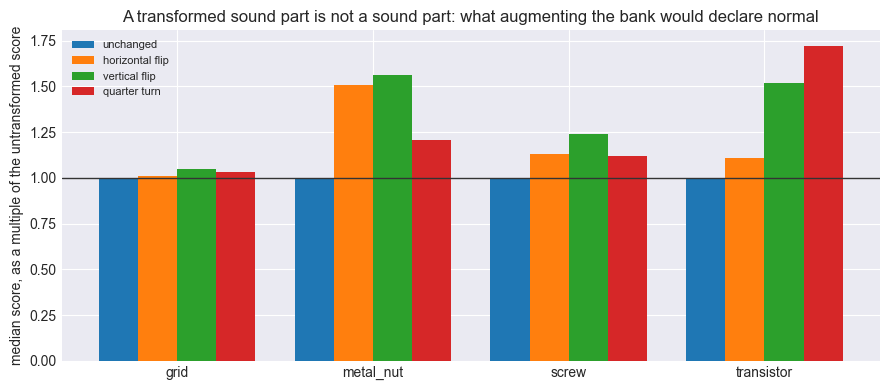

Largest effect: quarter turn, up to 1.72 times the untransformed score in transistor.

Every transform moves sound parts away from the bank, in every category. The
smallest effect is still an increase, so none of these categories is invariant to
any of them: the imaging is orientation-controlled and the parts are placed the
same way every time.

The decision follows directly: the memory bank carries no augmentation. A
flipped part scores like a defective one, so putting flipped parts into the bank
would teach the detector that an upside-down component is acceptable, which is
exactly the failure metal_nut/flip and transistor/misplaced are made of: two
defect types in this dataset are nothing but a part in the wrong orientation.


In [13]:
fig, ax = plt.subplots(figsize=(9, 4))
width = 0.2
positions = np.arange(len(CATEGORIES))
for offset, variant in enumerate(TRANSFORMS):
    ax.bar(positions + (offset - 1.5) * width, ratio[variant], width, label=variant)
ax.axhline(1.0, color='#333333', linewidth=1)
ax.set_xticks(positions, CATEGORIES)
ax.set_ylabel('median score, as a multiple of the untransformed score')
ax.set_title('A transformed sound part is not a sound part: what augmenting the bank would declare normal')
ax.legend(fontsize=8)
fig.tight_layout()
save_figure(fig, 'mvtec_prep_augmentation', subfolder=ASSETS)
plt.show()

worst_variant = ratio[[v for v in TRANSFORMS if v != 'unchanged']].max().idxmax()
print(f'Largest effect: {worst_variant}, up to '
      f'{ratio[worst_variant].max():.2f} times the untransformed score in '
      f'{ratio[worst_variant].idxmax()}.')
print()
print('Every transform moves sound parts away from the bank, in every category. The')
print('smallest effect is still an increase, so none of these categories is invariant to')
print('any of them: the imaging is orientation-controlled and the parts are placed the')
print('same way every time.')
print()
print('The decision follows directly: the memory bank carries no augmentation. A')
print('flipped part scores like a defective one, so putting flipped parts into the bank')
print('would teach the detector that an upside-down component is acceptable, which is')
print('exactly the failure metal_nut/flip and transistor/misplaced are made of: two')
print('defect types in this dataset are nothing but a part in the wrong orientation.')

## 7. What this notebook settles

Four decisions, each with the measurement that produced it.

In [14]:
print(f'1. The training folder is cut {1 - CALIBRATION_FRACTION:.0%}/{CALIBRATION_FRACTION:.0%} '
      f'at seed {SEED} into a memory bank and a')
print(f'   calibration set: {composition["bank"].sum()} sound parts to define normal, '
      f'{composition["calibration"].sum()} to price it. The shipped')
print('   test folder is scored once, in notebook 03. A threshold read off the bank')
print('   itself would be read off parts compared against copies of themselves.')
print(f'2. The resize destroys nothing. All {len(survival)} masks survive at both '
      f'{IMAGE_SIZES[0]} and {IMAGE_SIZES[1]},')
print(f'   the smallest defect keeping '
      f'{int(survival[survival[f"pixels_at_{IMAGE_SIZES[0]}"] > 0][f"pixels_at_{IMAGE_SIZES[0]}"].min())} pixels at '
      f'{IMAGE_SIZES[0]}. Square images, so no aspect ratio is lost.')
print('3. Averaging the frame is what would destroy it: the median defect is one part')
print(f'   in {dilution["one_part_in"].max():.0f} of a frame average in '
      f'{dilution["one_part_in"].idxmax()}, and at layer4 its most covered cell is')
print(f'   typically only {coarse_grid.min():.0%} defect. Notebook 03 keeps the grid, scores the')
print('   worst cell, and measures the alternatives rather than leaving this as arithmetic.')
print(f'4. No augmentation in the bank. Every transform tested moves sound parts away')
print(f'   from normal, the largest by {ratio[worst_variant].max():.2f} times, so augmenting would '
      f'widen normality')
print('   in exactly the direction two of this dataset\'s defect types occupy.')
print()
print('Next: 03_mvtec_modeling.ipynb, which builds the four memory banks, measures the')
print('design against the alternatives, and sets the operating point.')

1. The training folder is cut 70%/30% at seed 42 into a memory bank and a
   calibration set: 712 sound parts to define normal, 305 to price it. The shipped
   test folder is scored once, in notebook 03. A threshold read off the bank
   itself would be read off parts compared against copies of themselves.
2. The resize destroys nothing. All 309 masks survive at both 224 and 320,
   the smallest defect keeping 50 pixels at 224. Square images, so no aspect ratio is lost.
3. Averaging the frame is what would destroy it: the median defect is one part
   in 347 of a frame average in screw, and at layer4 its most covered cell is
   typically only 12% defect. Notebook 03 keeps the grid, scores the
   worst cell, and measures the alternatives rather than leaving this as arithmetic.
4. No augmentation in the bank. Every transform tested moves sound parts away
   from normal, the largest by 1.72 times, so augmenting would widen normality
   in exactly the direction two of this dataset's defect t